In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv('dataset/spam.csv',encoding='latin1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
data['v1'] = data['v1'].replace({'ham':0,'spam':1}).astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   int32 
 1   v2      5572 non-null   object
dtypes: int32(1), object(1)
memory usage: 65.4+ KB


In [6]:
data.isnull().sum()

v1    0
v2    0
dtype: int64

In [7]:
data['v2'].nunique()

5169

In [8]:
data.drop_duplicates(subset=['v2'],inplace=True)
print(len(data))

5169


<Axes: >

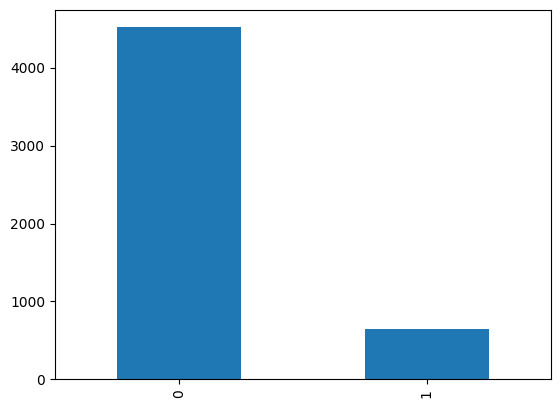

In [9]:
data['v1'].value_counts().plot(kind='bar')

   v1  count
0   0   4516
1   1    653


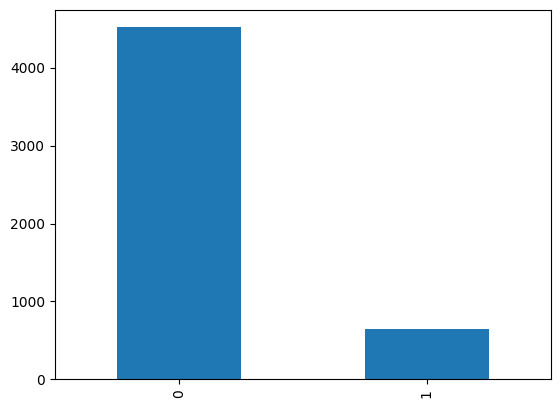

In [10]:
data['v1'].value_counts().plot(kind='bar')
print(data.groupby('v1').size().reset_index(name='count'))

In [11]:
X_data = data['v2']
y_data = data['v1']

In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_data)
sequences = tokenizer.texts_to_sequences(X_data)

In [13]:
word_to_index = tokenizer.word_index
vocab_size = len(word_to_index)
print(vocab_size)

8920


In [14]:
total_samples = len(sequences)
n_of_train = int(total_samples*0.8)
n_of_text = total_samples - n_of_train

In [15]:
max_len = 189
padded_data = pad_sequences(sequences,maxlen=max_len)
print(padded_data)

[[   0    0    0 ...   57 4014  137]
 [   0    0    0 ...  435    6 1767]
 [   0    0    0 ...  707  437 4015]
 ...
 [   0    0    0 ...   99  240 8919]
 [   0    0    0 ...  196   12   53]
 [   0    0    0 ...    2   63  283]]


In [16]:
X_train = padded_data[:n_of_train]
X_test = padded_data[n_of_train:]

y_train = np.array(y_data[:n_of_train])
y_test = np.array(y_data[n_of_train:])

In [17]:
# RNN 스팸 분류

model = Sequential()
model.add(Embedding(vocab_size,32))
model.add(SimpleRNN(32))
model.add(Dense(1,activation='sigmoid'))

In [18]:
model.compile(
    loss='binary_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
52/52 [==============================] - 12s 197ms/step - loss: 0.4989 - accuracy: 0.8159 - val_loss: 0.3400 - val_accuracy: 0.8742
Epoch 2/10
52/52 [==============================] - 10s 192ms/step - loss: 0.2292 - accuracy: 0.9374 - val_loss: 0.1362 - val_accuracy: 0.9661
Epoch 3/10
52/52 [==============================] - 10s 194ms/step - loss: 0.0972 - accuracy: 0.9779 - val_loss: 0.0975 - val_accuracy: 0.9698
Epoch 4/10
52/52 [==============================] - 10s 194ms/step - loss: 0.0583 - accuracy: 0.9843 - val_loss: 0.0896 - val_accuracy: 0.9746
Epoch 5/10
52/52 [==============================] - 10s 195ms/step - loss: 0.0346 - accuracy: 0.9912 - val_loss: 0.1202 - val_accuracy: 0.9625
Epoch 6/10
52/52 [==============================] - 10s 193ms/step - loss: 0.0379 - accuracy: 0.9900 - val_loss: 0.0638 - val_accuracy: 0.9782
Epoch 7/10
52/52 [==============================] - 10s 196ms/step - loss: 0.0145 - accuracy: 0.9958 - val_loss: 0.0599 - val_accuracy: 0.9831

In [25]:
def predict_spam(new_text):
    sequence = tokenizer.texts_to_sequences([new_text])
    padded = pad_sequences(sequence,maxlen=max_len)
    prediction = model.predict(padded)[0][0]

    if prediction > 0.5:
        print("스팸입니다. (확률 : %.2f)" %prediction)
    else:
        print("정상 메일입니다. (확률 : %.2f)" % (1 - prediction))

In [26]:
predict_spam("Congratulations! You've won a $1,000 gift card. Click here to claim.")
predict_spam("I have submitted the relevant materials. Please review them.")

1/1 [==============================] - 0s 53ms/step
스팸입니다. (확률 : 0.98)
1/1 [==============================] - 0s 37ms/step
정상 메일입니다. (확률 : 1.00)
